# Nigeria Climate EDA
## 10 Academy KAIM9 - Week 0

In [1]:
# NIGERIA EDA - COMPLETE SETUP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.style.use('seaborn-v0_8')

# Load & Parse Data
df = pd.read_csv('../data/nigeria.csv')
df['Country'] = 'Nigeria'
df.replace(-999, np.nan, inplace=True)
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month
df.drop_duplicates(inplace=True)

print("Libraries imported!")
print("Data loaded!")
print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
df.head()

Libraries imported!
Data loaded!
Shape: (4108, 15)
Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.230,29.250,22.060,7.190,0.000,68.260,1.730,2.610,100.860,13.360,Nigeria,2015-01-01,1
1,2015,2,26.160,29.410,22.870,6.540,0.000,73.230,1.420,1.950,100.940,15.370,Nigeria,2015-01-02,1
2,2015,3,25.660,29.020,22.630,6.390,0.000,78.710,1.690,2.330,101.060,15.980,Nigeria,2015-01-03,1
3,2015,4,24.110,27.270,19.920,7.350,0.000,63.660,2.150,3.800,101.090,11.650,Nigeria,2015-01-04,1
4,2015,5,23.400,27.280,18.180,9.100,0.000,59.450,1.880,3.480,101.030,10.400,Nigeria,2015-01-05,1


In [2]:
# Missing Values Report
missing_pct = (df.isna().sum() / len(df)) * 100
print("Missing Values Report:")
print(missing_pct[missing_pct > 0])
print("\n No missing values!" if missing_pct.sum() == 0 else "Missing values found!")

# Outlier Detection
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df[cols].dropna()))
outlier_mask = pd.DataFrame(z_scores > 3, columns=cols)
outlier_counts = outlier_mask.sum()

print("\nOutlier counts per column (|Z| > 3):")
for col in cols:
    print(f"  {col}: {outlier_counts[col]} outliers")
print(f"\nTotal outlier rows: {outlier_mask.any(axis=1).sum()}")

Missing Values Report:
Series([], dtype: float64)

 No missing values!

Outlier counts per column (|Z| > 3):
  T2M: 10 outliers
  T2M_MAX: 1 outliers
  T2M_MIN: 68 outliers
  PRECTOTCORR: 75 outliers
  RH2M: 128 outliers
  WS2M: 5 outliers
  WS2M_MAX: 10 outliers

Total outlier rows: 225


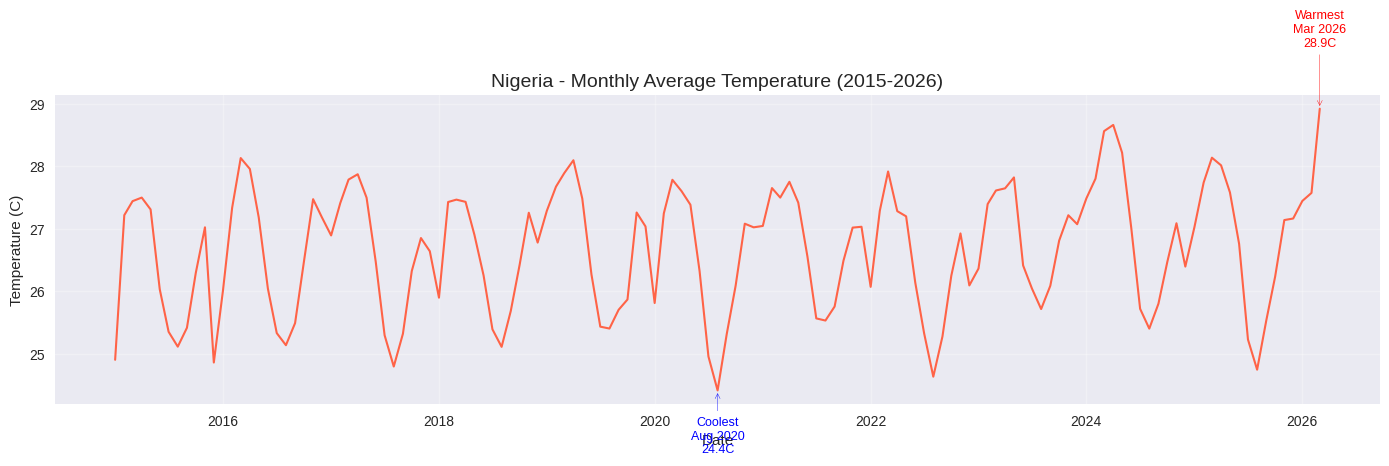

Temperature time series done!


In [3]:
# Plot 1: Monthly Average Temperature
monthly_temp = df.groupby(df['Date'].dt.to_period('M'))['T2M'].mean()
monthly_temp.index = monthly_temp.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_temp.index, monthly_temp.values, color='tomato', linewidth=1.5)

warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()

ax.annotate(f'Warmest\n{warmest.strftime("%b %Y")}\n{monthly_temp.max():.1f}C',
            xy=(warmest, monthly_temp.max()),
            xytext=(warmest, monthly_temp.max() + 1),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=9, color='red', ha='center')

ax.annotate(f'Coolest\n{coolest.strftime("%b %Y")}\n{monthly_temp.min():.1f}C',
            xy=(coolest, monthly_temp.min()),
            xytext=(coolest, monthly_temp.min() - 1),
            arrowprops=dict(arrowstyle='->', color='blue'),
            fontsize=9, color='blue', ha='center')

ax.set_title('Nigeria - Monthly Average Temperature (2015-2026)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (C)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/nigeria_temp_timeseries.png', dpi=150)
plt.show()
print("Temperature time series done!")

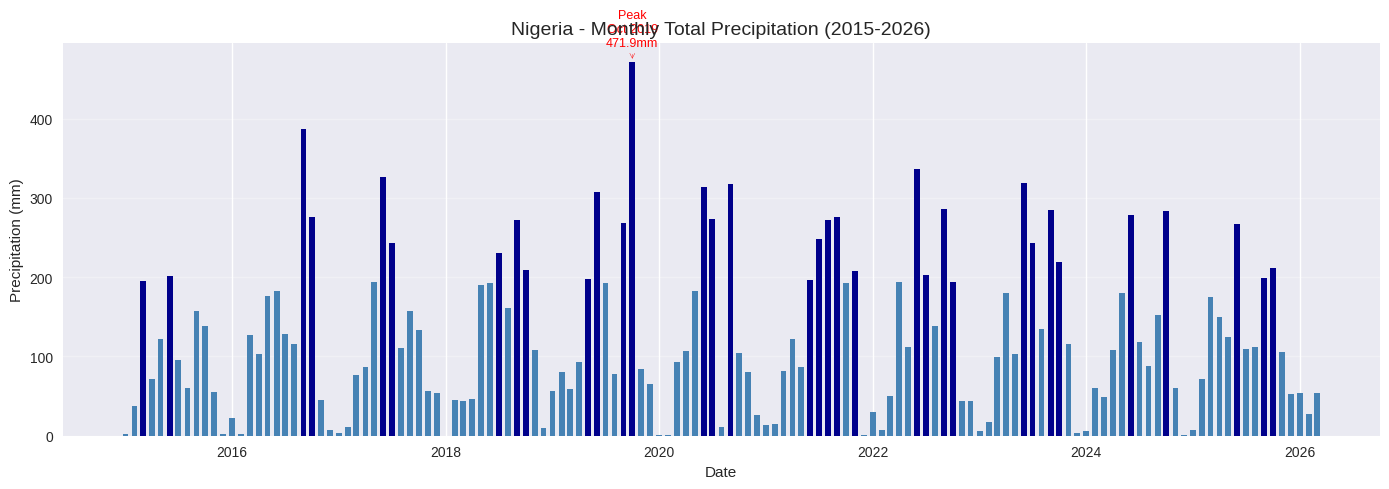

Precipitation bar chart done!


In [4]:
# Plot 2: Monthly Total Precipitation
monthly_precip = df.groupby(df['Date'].dt.to_period('M'))['PRECTOTCORR'].sum()
monthly_precip.index = monthly_precip.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['steelblue' if v < monthly_precip.quantile(0.75) else 'darkblue'
          for v in monthly_precip.values]
ax.bar(monthly_precip.index, monthly_precip.values, color=colors, width=20)

peak = monthly_precip.idxmax()
ax.annotate(f'Peak\n{peak.strftime("%b %Y")}\n{monthly_precip.max():.1f}mm',
            xy=(peak, monthly_precip.max()),
            xytext=(peak, monthly_precip.max() + 20),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=9, color='red', ha='center')

ax.set_title('Nigeria - Monthly Total Precipitation (2015-2026)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Precipitation (mm)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../notebooks/nigeria_precip_barchart.png', dpi=150)
plt.show()
print("Precipitation bar chart done!")

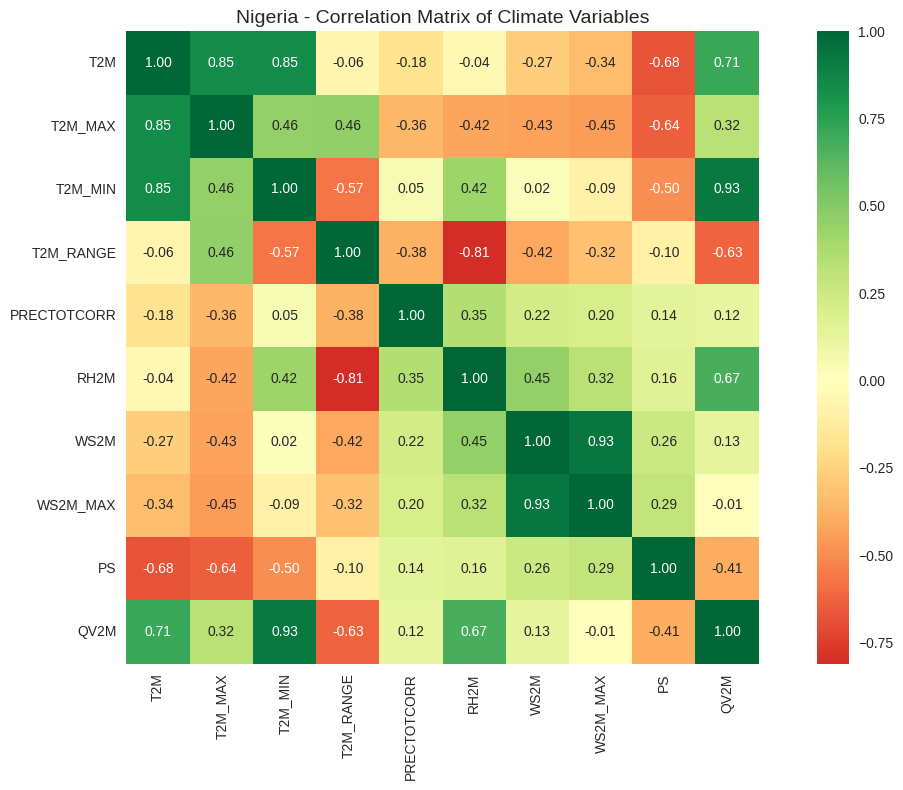

Correlation heatmap done!


In [5]:
# Plot 3: Correlation Heatmap
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE',
        'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']

fig, ax = plt.subplots(figsize=(12, 8))
corr_matrix = df[cols].corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            ax=ax)

ax.set_title('Nigeria - Correlation Matrix of Climate Variables', fontsize=14)
plt.tight_layout()
plt.savefig('../notebooks/nigeria_correlation_heatmap.png', dpi=150)
plt.show()
print("Correlation heatmap done!")

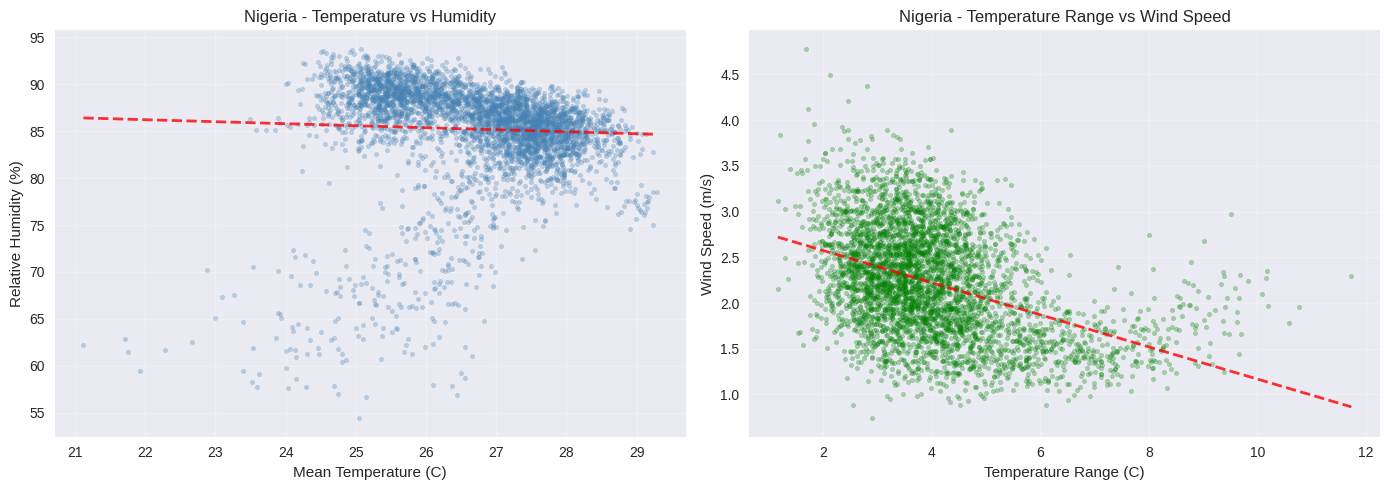

Scatter plots done!


In [6]:
# Plot 4: Scatter Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: T2M vs RH2M
axes[0].scatter(df['T2M'], df['RH2M'],
                alpha=0.3, color='steelblue', s=10)
axes[0].set_xlabel('Mean Temperature (C)')
axes[0].set_ylabel('Relative Humidity (%)')
axes[0].set_title('Nigeria - Temperature vs Humidity')
axes[0].grid(True, alpha=0.3)

# Trend line
z = np.polyfit(df['T2M'].dropna(), df['RH2M'].dropna(), 1)
p = np.poly1d(z)
axes[0].plot(sorted(df['T2M'].dropna()),
             p(sorted(df['T2M'].dropna())),
             "r--", alpha=0.8, linewidth=2)

# Plot 2: T2M_RANGE vs WS2M
axes[1].scatter(df['T2M_RANGE'], df['WS2M'],
                alpha=0.3, color='green', s=10)
axes[1].set_xlabel('Temperature Range (C)')
axes[1].set_ylabel('Wind Speed (m/s)')
axes[1].set_title('Nigeria - Temperature Range vs Wind Speed')
axes[1].grid(True, alpha=0.3)

# Trend line
z2 = np.polyfit(df['T2M_RANGE'].dropna(), df['WS2M'].dropna(), 1)
p2 = np.poly1d(z2)
axes[1].plot(sorted(df['T2M_RANGE'].dropna()),
             p2(sorted(df['T2M_RANGE'].dropna())),
             "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.savefig('../notebooks/nigeria_scatter_plots.png', dpi=150)
plt.show()
print("Scatter plots done!")

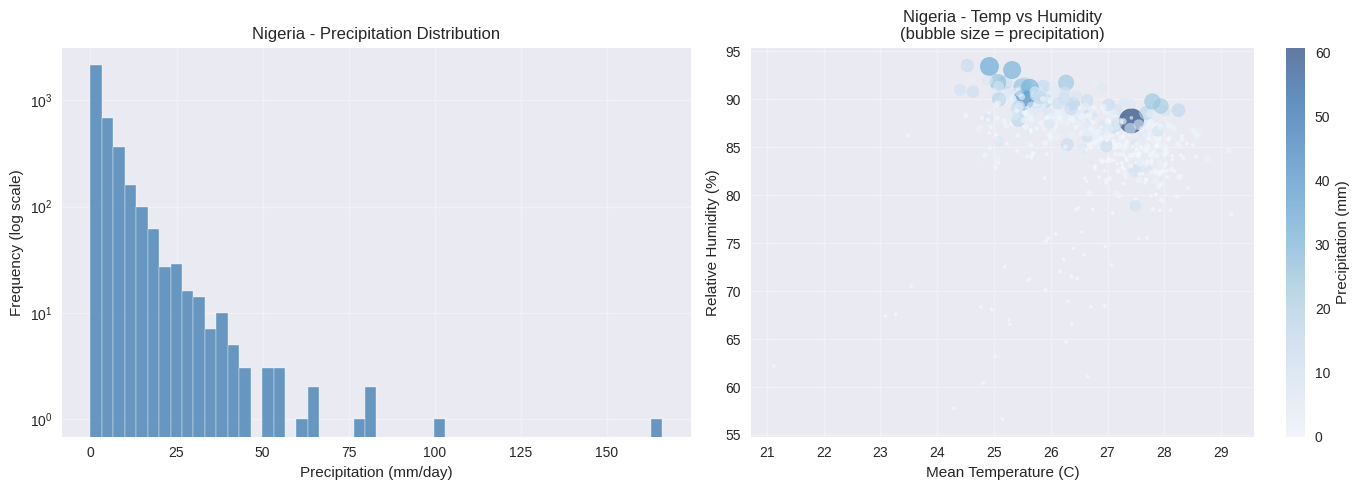

Distribution analysis done!


In [7]:
# Plot 5: Distribution Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of PRECTOTCORR
precip_nonzero = df['PRECTOTCORR'][df['PRECTOTCORR'] > 0]
axes[0].hist(precip_nonzero, bins=50, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_xlabel('Precipitation (mm/day)')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_title('Nigeria - Precipitation Distribution')
axes[0].grid(True, alpha=0.3)

# Bubble Chart
sample = df.sample(500, random_state=42)
bubble_size = (sample['PRECTOTCORR'] + 1) * 5
scatter = axes[1].scatter(sample['T2M'], sample['RH2M'],
                          s=bubble_size,
                          c=sample['PRECTOTCORR'],
                          cmap='Blues',
                          alpha=0.6)
plt.colorbar(scatter, ax=axes[1], label='Precipitation (mm)')
axes[1].set_xlabel('Mean Temperature (C)')
axes[1].set_ylabel('Relative Humidity (%)')
axes[1].set_title('Nigeria - Temp vs Humidity\n(bubble size = precipitation)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/nigeria_distribution.png', dpi=150)
plt.show()
print("Distribution analysis done!")

In [8]:
# Export cleaned Nigeria data
import os
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/nigeria_clean.csv', index=False)
print("Cleaned data exported to data/nigeria_clean.csv")
print(f"Final shape: {df.shape}")

Cleaned data exported to data/nigeria_clean.csv
Final shape: (4108, 15)
